# 제품 이상여부 판별 프로젝트


## 데이터 불러오기


### 필수 라이브러리


In [1]:
import os
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import random
import torch
import warnings
warnings.filterwarnings("ignore")

### 데이터 읽어오기


In [2]:
ROOT_DIR = "data"
RANDOM_STATE = 736665
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(RANDOM_STATE)


seed_everything(RANDOM_STATE)
# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))
test_data = pd.read_csv(os.path.join(ROOT_DIR, "test.csv"))

In [3]:
# test_data에는 target 컬럼이 있지만 다 결측치
# test_data에 Set ID가 있어서 열 하나가 train_data보다 많음
train_data.shape, test_data.shape

((40506, 464), (17361, 465))

## 데이터 전처리

### 전체 행이 결측치이거나 똑같은 값인 칼럼 삭제

In [4]:
import pandas as pd

def drop_columns(df):

    drop_cols = []
    # 전체 행이 결측치인 칼럼 삭제
    base_col = df.columns
    df.dropna(axis=1, how='all', inplace=True)
    # drop된 컬럼 확인
    dif_col = list(set(base_col) - set(df.columns))
    drop_cols.extend(dif_col)
    print('모든 값이 결측치인 열 제거 진행')
    print(f'drop한 컬럼 : {dif_col}')
    print(f'drop한 컬럼 개수 : {len(dif_col)}개')

    # 특정 컬럼의 값이 다 같은 경우 컬럼 제거
    base_col = df.columns
    for col in df.columns:
        if (df[col].nunique() == 1) and (df[col].isnull().sum() == 0):
            df.drop(columns=col, inplace=True)
    dif_col = list(set(base_col) - set(df.columns))
    drop_cols.extend(dif_col)
    print('모든 값이 같은 열 제거 진행')
    print(f'drop한 컬럼 : {dif_col}')
    print(f'drop한 컬럼 개수 : {len(dif_col)}개')


    return df, drop_cols

train_data, drop_cols = drop_columns(train_data)
test_data = test_data.drop(columns=drop_cols)
train_data.shape, test_data.shape

모든 값이 결측치인 열 제거 진행
drop한 컬럼 : ['Stage2 Circle4 Distance Speed Unit Time_Dam', 'Head Zero Position Z Unit Time_Dam', 'HEAD Standby Position Z Unit Time_Dam', 'DISCHARGED TIME OF RESIN(Stage1) Judge Value_Fill1', 'Dispense Volume(Stage3) Unit Time_Fill1', 'THICKNESS 3 Unit Time_Dam', 'Stage2 Circle3 Distance Speed Unit Time_Dam', 'Head Purge Position Z Judge Value_Fill1', 'Machine Tact time Unit Time_Dam', 'HEAD Standby Position X Unit Time_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage2) Unit Time_Dam', 'Dispense Volume(Stage3) Judge Value_Fill1', 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Judge Value_Fill2', 'Stage3 Line1 Distance Speed Judge Value_Dam', 'DISCHARGED SPEED OF RESIN Judge Value_Fill1', 'DISCHARGED TIME OF RESIN(Stage2) Unit Time_Fill2', 'HEAD NORMAL COORDINATE Z AXIS(Stage3) Unit Time_Fill2', 'Head Purge Position Y Unit Time_Fill2', 'CURE STANDBY POSITION Θ Judge Value_Dam', 'Stage3 Line2 Distance Speed Judge Value_Dam', 'CURE STANDBY POSITION X Judge Value_Fill2', 'Stage3 Cir

((40506, 151), (17361, 152))

### 중복 컬럼 제거

In [5]:
columns_dict = {}
duplicate_dict = {}

for col in train_data.columns:
    # 각 열의 해시 값을 계산하여 문자열로 변환
    col_hash = tuple(train_data[col].tolist())

    # 이미 존재하는 해시 값이라면 중복으로 처리
    if col_hash in columns_dict:
        existing_col = columns_dict[col_hash]
        if existing_col in duplicate_dict:
            duplicate_dict[existing_col].append(col)
        else:
            duplicate_dict[existing_col] = [col]
    else:
        columns_dict[col_hash] = col
duplicate_dict

{'CURE END POSITION Θ Collect Result_Dam': ['CURE START POSITION Θ Collect Result_Dam'],
 'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam': ['HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam'],
 'HEAD Standby Position Y Collect Result_Dam': ['Head Purge Position Y Collect Result_Dam'],
 'Stage1 Circle2 Distance Speed Collect Result_Dam': ['Stage1 Circle3 Distance Speed Collect Result_Dam',
  'Stage1 Circle4 Distance Speed Collect Result_Dam'],
 'Stage1 Line1 Distance Speed Collect Result_Dam': ['Stage1 Line3 Distance Speed Collect Result_Dam'],
 'Stage2 Circle2 Distance Speed Collect Result_Dam': ['Stage2 Circle3 Distance Speed Collect Result_Dam',
  'Stage2 Circle4 Distance Speed Collect Result_Dam',
  'Stage2 Line1 Distance Speed Collect Result_Dam'],
 'Stage3 Circle2 Distance Speed Collect Result_Dam': ['Stage3 Circle3 Distance Speed Collect Result_Dam',
  'Stage3 Circle4 Distance Speed Collect Result_Dam'],
 'Stage3 Line1 Distance Speed Collect Result_Dam': ['Stag

In [6]:
delete_cols = []
for col in list(duplicate_dict.values()):
    delete_cols.extend(col)
delete_cols

['CURE START POSITION Θ Collect Result_Dam',
 'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam',
 'Head Purge Position Y Collect Result_Dam',
 'Stage1 Circle3 Distance Speed Collect Result_Dam',
 'Stage1 Circle4 Distance Speed Collect Result_Dam',
 'Stage1 Line3 Distance Speed Collect Result_Dam',
 'Stage2 Circle3 Distance Speed Collect Result_Dam',
 'Stage2 Circle4 Distance Speed Collect Result_Dam',
 'Stage2 Line1 Distance Speed Collect Result_Dam',
 'Stage3 Circle3 Distance Speed Collect Result_Dam',
 'Stage3 Circle4 Distance Speed Collect Result_Dam',
 'Stage3 Line3 Distance Speed Collect Result_Dam',
 'Model.Suffix_AutoClave',
 'Model.Suffix_Fill1',
 'Model.Suffix_Fill2',
 'Workorder_AutoClave',
 'Workorder_Fill1',
 'Workorder_Fill2',
 'GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave',
 'GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill2',
 'Head Pur

In [7]:
train_data.drop(columns=delete_cols, inplace=True)
test_data.drop(columns=delete_cols, inplace=True)
train_data.shape, test_data.shape

((40506, 125), (17361, 126))

### 파생 변수 생성

#### 상관관계가 1, -1인 열 확인 - 할지 말지는 선택
- 특정 열들의 unique값이 아주 적은 경우

In [8]:
# train_data의 수치형 데이터
num_cols = train_data.select_dtypes(include=["int64", "float64"]).columns
corr_matrix = train_data[num_cols].corr()
corr_matrix

,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,CURE SPEED Collect Result_Dam,CURE START POSITION X Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,Dispense Volume(Stage1) Collect Result_Dam,...,Head Clean Position X Collect Result_Fill2,Head Clean Position Y Collect Result_Fill2,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2
CURE END POSITION X Collect Result_Dam,1.000000,1.000000,1.000000,0.072784,-1.000000,0.218303,0.274864,0.284963,0.273605,0.270166,...,-0.279744,0.279744,-0.279744,-0.279744,-0.279744,0.268463,0.415902,-0.167640,0.190253,0.148343
CURE END POSITION Z Collect Result_Dam,1.000000,1.000000,1.000000,0.072784,-1.000000,0.218303,0.274864,0.284963,0.273605,0.270166,...,-0.279744,0.279744,-0.279744,-0.279744,-0.279744,0.268463,0.415902,-0.167640,0.190253,0.148343
CURE END POSITION Θ Collect Result_Dam,1.000000,1.000000,1.000000,0.072784,-1.000000,0.218303,0.274864,0.284963,0.273605,0.270166,...,-0.279744,0.279744,-0.279744,-0.279744,-0.279744,0.268463,0.415902,-0.167640,0.190253,0.148343
CURE SPEED Collect Result_Dam,0.072784,0.072784,0.072784,1.000000,-0.072784,0.411677,0.049065,0.313518,0.036990,0.190544,...,-0.327282,0.327282,-0.327282,-0.327282,-0.327282,0.500878,0.322051,-0.245664,0.106939,0.172034
CURE START POSITION X Collect Result_Dam,-1.000000,-1.000000,-1.000000,-0.072784,1.000000,-0.218303,-0.274864,-0.284963,-0.273605,-0.270166,...,0.279744,-0.279744,0.279744,0.279744,0.279744,-0.268463,-0.415902,0.167640,-0.190253,-0.148343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Machine Tact time Collect Result_Fill2,0.268463,0.268463,0.268463,0.500878,-0.268463,0.806875,0.277224,0.783062,0.267644,0.487390,...,-0.966389,0.966389,-0.966389,-0.966389,-0.966389,1.000000,0.911833,-0.723120,0.625772,0.505677
PalletID Collect Result_Fill2,0.415902,0.415902,0.415902,0.322051,-0.415902,0.751740,0.368828,0.762839,0.362118,0.518180,...,-0.935672,0.935672,-0.935672,-0.935672,-0.935672,0.911833,1.000000,-0.691297,0.632636,0.473422
Production Qty Collect Result_Fill2,-0.167640,-0.167640,-0.167640,-0.245664,0.167640,-0.595208,-0.177210,-0.587332,-0.171922,-0.304106,...,0.748361,-0.748361,0.748361,0.748361,0.748361,-0.723120,-0.691297,1.000000,-0.509699,-0.369916
Receip No Collect Result_Fill2,0.190253,0.190253,0.190253,0.106939,-0.190253,0.553829,0.165186,0.508740,0.161199,0.233516,...,-0.680962,0.680962,-0.680962,-0.680962,-0.680962,0.625772,0.632636,-0.509699,1.000000,0.312106


In [9]:
# 상관계수 1 또는 -1인 쌍만 추출
strong_corrs = corr_matrix[(corr_matrix >= 0.99999) | (corr_matrix <= -0.99999) ]
strong_corrs

,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,CURE SPEED Collect Result_Dam,CURE START POSITION X Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,Dispense Volume(Stage1) Collect Result_Dam,...,Head Clean Position X Collect Result_Fill2,Head Clean Position Y Collect Result_Fill2,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2
CURE END POSITION X Collect Result_Dam,1.0,1.0,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURE END POSITION Z Collect Result_Dam,1.0,1.0,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURE END POSITION Θ Collect Result_Dam,1.0,1.0,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURE SPEED Collect Result_Dam,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURE START POSITION X Collect Result_Dam,-1.0,-1.0,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Machine Tact time Collect Result_Fill2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
PalletID Collect Result_Fill2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Production Qty Collect Result_Fill2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Receip No Collect Result_Fill2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [10]:
train_data[['CURE END POSITION X Collect Result_Dam', 'CURE END POSITION Z Collect Result_Dam']].drop_duplicates()

,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam
0,240.0,2.5
2,1000.0,12.5


In [11]:
col_list = strong_corrs.columns
corr_list = []
for col in col_list:
    corr_cols = list(strong_corrs[strong_corrs[col].notnull()].index)

    if (len(corr_cols) > 1) and (corr_cols not in corr_list):
        print('서로 상관관계가 1인 집단 크기 :', len(corr_cols))
        corr_list.append(corr_cols)

서로 상관관계가 1인 집단 크기 : 4
서로 상관관계가 1인 집단 크기 : 18
서로 상관관계가 1인 집단 크기 : 2
서로 상관관계가 1인 집단 크기 : 2
서로 상관관계가 1인 집단 크기 : 2
서로 상관관계가 1인 집단 크기 : 2
서로 상관관계가 1인 집단 크기 : 3


In [12]:
corr_list

[['CURE END POSITION X Collect Result_Dam',
  'CURE END POSITION Z Collect Result_Dam',
  'CURE END POSITION Θ Collect Result_Dam',
  'CURE START POSITION X Collect Result_Dam'],
 ['HEAD Standby Position Y Collect Result_Dam',
  'HEAD Standby Position Z Collect Result_Dam',
  'Head Clean Position X Collect Result_Dam',
  'Head Clean Position Y Collect Result_Dam',
  'Head Zero Position X Collect Result_Dam',
  'HEAD Standby Position Y Collect Result_Fill1',
  'HEAD Standby Position Z Collect Result_Fill1',
  'Head Clean Position X Collect Result_Fill1',
  'Head Clean Position Y Collect Result_Fill1',
  'Head Clean Position Z Collect Result_Fill1',
  'Head Purge Position X Collect Result_Fill1',
  'HEAD Standby Position Y Collect Result_Fill2',
  'HEAD Standby Position Z Collect Result_Fill2',
  'Head Clean Position X Collect Result_Fill2',
  'Head Clean Position Y Collect Result_Fill2',
  'Head Clean Position Z Collect Result_Fill2',
  'Head Purge Position X Collect Result_Fill2',
  'H

In [13]:
print('집단 별로 합하기 전의 고유값과 합한 후의 고유값 비교')
for i in range(len(corr_list)):
    print('전', len(train_data[corr_list[i]].drop_duplicates()), '후', train_data[corr_list[i]].sum(axis=1).nunique())

집단 별로 합하기 전의 고유값과 합한 후의 고유값 비교
전 2 후 2
전 2 후 2
전 5 후 5
전 10 후 10
전 26 후 22
전 2 후 1
전 3 후 2


In [14]:
# 합하기 전과 후의 고유값이 같은 경우는 그냥 합침
for i in range(4):
    train_data['SUM ' + corr_list[i][0]] = train_data[corr_list[i]].sum(axis=1)
    test_data['SUM ' + corr_list[i][0]] = test_data[corr_list[i]].sum(axis=1)
    print(corr_list[i])
    train_data.drop(columns=corr_list[i], inplace=True)
    test_data.drop(columns=corr_list[i], inplace=True)
train_data.shape, test_data.shape

['CURE END POSITION X Collect Result_Dam', 'CURE END POSITION Z Collect Result_Dam', 'CURE END POSITION Θ Collect Result_Dam', 'CURE START POSITION X Collect Result_Dam']
['HEAD Standby Position Y Collect Result_Dam', 'HEAD Standby Position Z Collect Result_Dam', 'Head Clean Position X Collect Result_Dam', 'Head Clean Position Y Collect Result_Dam', 'Head Zero Position X Collect Result_Dam', 'HEAD Standby Position Y Collect Result_Fill1', 'HEAD Standby Position Z Collect Result_Fill1', 'Head Clean Position X Collect Result_Fill1', 'Head Clean Position Y Collect Result_Fill1', 'Head Clean Position Z Collect Result_Fill1', 'Head Purge Position X Collect Result_Fill1', 'HEAD Standby Position Y Collect Result_Fill2', 'HEAD Standby Position Z Collect Result_Fill2', 'Head Clean Position X Collect Result_Fill2', 'Head Clean Position Y Collect Result_Fill2', 'Head Clean Position Z Collect Result_Fill2', 'Head Purge Position X Collect Result_Fill2', 'Head Purge Position Z Collect Result_Fill2']

((40506, 103), (17361, 104))

In [15]:
train_data[corr_list[4]].drop_duplicates()

,HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1,HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1
0,430.0,429.8
1,430.5,430.8
2,1323.5,1322.5
3,1322.5,1322.8
4,430.5,430.5
6,430.8,430.5
24,430.3,430.0
25,431.1,430.8
48,429.8,430.0
56,1323.0,1322.8


In [16]:
temp = train_data[corr_list[4]].drop_duplicates()
temp['sum'] =  temp[corr_list[4][0]] + ((temp[corr_list[4][1]] - temp[corr_list[4][0]]) / temp[corr_list[4][0]] * 100)
temp['sum']

0         429.953488
1         430.569686
2        1323.424443
3        1322.522684
4         430.500000
6         430.730362
24        430.230281
25        431.030411
48        429.846533
56       1322.984883
66       1323.447110
71       1324.924528
111      1325.524562
121      1323.147098
127       430.523229
450      1323.200000
569       430.183802
605      1324.462250
621       429.730200
661       430.960821
703      1323.262216
844      1322.707560
1432     1325.184908
1450     1324.762258
2687     1322.852918
37520    1332.274790
Name: sum, dtype: float64

In [17]:
train_data['DELTA ' + corr_list[4][0]] = train_data[corr_list[4][0]] + ((train_data[corr_list[4][1]] - train_data[corr_list[4][0]]) / train_data[corr_list[4][0]] * 100)
test_data['DELTA ' + corr_list[4][0]] = test_data[corr_list[4][0]] + ((test_data[corr_list[4][1]] - test_data[corr_list[4][0]]) / test_data[corr_list[4][0]] * 100)
train_data.drop(columns=corr_list[4], inplace=True)
test_data.drop(columns=corr_list[4], inplace=True)
train_data.shape, test_data.shape

((40506, 102), (17361, 103))

In [18]:
train_data[corr_list[5]].drop_duplicates()

,CURE END POSITION X Collect Result_Fill2,CURE START POSITION X Collect Result_Fill2
0,240,1020
569,1020,240


In [19]:
train_data['DELTA ' + corr_list[5][0]] = train_data[corr_list[5][0]] - train_data[corr_list[5][1]]
test_data['DELTA ' + corr_list[5][0]] = test_data[corr_list[5][0]] - test_data[corr_list[5][1]]
train_data.drop(columns=corr_list[5], inplace=True)
test_data.drop(columns=corr_list[5], inplace=True)
train_data.shape, test_data.shape

((40506, 101), (17361, 102))

In [20]:
train_data[corr_list[6]].drop_duplicates()

,HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2,HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2,HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2
0,428.0,427.9,243.7
1,427.9,428.0,243.7
2,1324.2,1324.2,243.5


In [21]:
train_data['DELTA ' + corr_list[6][0]]  = (train_data[corr_list[6][1]] - train_data[corr_list[6][0]] + train_data[corr_list[6][2]])
test_data['DELTA ' + corr_list[6][0]]  = (test_data[corr_list[6][1]] - test_data[corr_list[6][0]] + test_data[corr_list[6][2]])
train_data.drop(columns=corr_list[6], inplace=True)
test_data.drop(columns=corr_list[6], inplace=True)
train_data.shape, test_data.shape

((40506, 99), (17361, 100))

#### 상관관계 범위를 1, -1이 아닌 0.99, -0.99로 변경 시 확인

In [22]:
num_cols = train_data.select_dtypes(include=["int64", "float64"]).columns
corr_matrix = train_data[num_cols].corr()

# 상관계수 1 또는 -1인 쌍만 추출
strong_corrs = corr_matrix[(corr_matrix >= 0.99)  | (corr_matrix <= -0.99) ]
strong_corrs

,CURE SPEED Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,Dispense Volume(Stage1) Collect Result_Dam,Dispense Volume(Stage2) Collect Result_Dam,Dispense Volume(Stage3) Collect Result_Dam,HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam,HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam,...,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,SUM CURE END POSITION X Collect Result_Dam,SUM HEAD Standby Position Y Collect Result_Dam,SUM Head Clean Position Z Collect Result_Dam,SUM Stage2 Circle2 Distance Speed Collect Result_Dam,DELTA HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1,DELTA CURE END POSITION X Collect Result_Fill2,DELTA HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2
CURE SPEED Collect Result_Dam,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISCHARGED SPEED OF RESIN Collect Result_Dam,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,NaN,NaN,1.000000,NaN,0.999476,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,NaN,NaN,0.999476,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SUM Head Clean Position Z Collect Result_Dam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.999443,1.0,NaN,NaN,NaN,NaN
SUM Stage2 Circle2 Distance Speed Collect Result_Dam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
DELTA HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.998797,NaN,NaN,NaN,1.0,NaN,NaN
DELTA CURE END POSITION X Collect Result_Fill2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [23]:
# 상관 행렬 계산 (예: df는 데이터프레임)
corr_matrix = train_data[num_cols].corr()

# 절대값이 0.99 이상인 상관관계 쌍을 필터링
high_corr_pairs = corr_matrix[(corr_matrix.abs() >= 0.99)]
high_corr_pairs.fillna(0, inplace=True)
# 상관관계가 0.99 이상인 컬럼 쌍 추출
correlated_pairs = []
for i in range(len(high_corr_pairs.columns)):
    for j in range(i):
        if (high_corr_pairs.iloc[i, j] != 0):
            correlated_pairs.append((high_corr_pairs.index[i], high_corr_pairs.columns[j], high_corr_pairs.iloc[i, j]))

# 결과 출력
for pair in correlated_pairs:
    print(f'{pair[0]}와 {pair[1]}의 상관관계: {pair[2]}')

DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam와 DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam의 상관관계: 0.9994755091064483
Dispense Volume(Stage3) Collect Result_Dam와 Dispense Volume(Stage1) Collect Result_Dam의 상관관계: 0.9993794627149966
HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam와 HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam의 상관관계: 0.997222491026016
Head Zero Position Y Collect Result_Dam와 Head Purge Position X Collect Result_Dam의 상관관계: -0.9991435701922116
Head Zero Position Z Collect Result_Dam와 Head Purge Position X Collect Result_Dam의 상관관계: -0.9991490400388723
Head Zero Position Z Collect Result_Dam와 Head Zero Position Y Collect Result_Dam의 상관관계: 0.9999168250383242
Machine Tact time Collect Result_Dam와 Head Purge Position X Collect Result_Dam의 상관관계: -0.9914490717908745
Machine Tact time Collect Result_Dam와 Head Zero Position Y Collect Result_Dam의 상관관계: 0.9928418093572455
Machine Tact time Collect Result_Dam와 Head Zero Position Z Collect Result_Dam의 상관

In [24]:
temp = pd.DataFrame(strong_corrs.notnull().sum())
temp.columns = ['group_size']
temp = temp[temp['group_size'] > 1]
print(temp['group_size'].unique())
temp


[ 2  4  3 10  8  9]


,group_size
DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,2
DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,2
Dispense Volume(Stage1) Collect Result_Dam,2
Dispense Volume(Stage3) Collect Result_Dam,2
HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam,4
HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam,4
HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam,3
Head Purge Position X Collect Result_Dam,10
Head Zero Position Y Collect Result_Dam,10
Head Zero Position Z Collect Result_Dam,10


In [25]:
col_list = strong_corrs.columns
corr_list = []
for col in col_list:
    corr_cols = list(strong_corrs[strong_corrs[col].notnull()].index)

    if (len(corr_cols) > 1) and (corr_cols not in corr_list):
        print('서로 상관관계가 0.99이상인 집단 크기 :', len(corr_cols))
        corr_list.append(corr_cols)

서로 상관관계가 0.99이상인 집단 크기 : 2
서로 상관관계가 0.99이상인 집단 크기 : 2
서로 상관관계가 0.99이상인 집단 크기 : 4
서로 상관관계가 0.99이상인 집단 크기 : 3
서로 상관관계가 0.99이상인 집단 크기 : 10
서로 상관관계가 0.99이상인 집단 크기 : 8
서로 상관관계가 0.99이상인 집단 크기 : 3
서로 상관관계가 0.99이상인 집단 크기 : 3
서로 상관관계가 0.99이상인 집단 크기 : 8
서로 상관관계가 0.99이상인 집단 크기 : 3
서로 상관관계가 0.99이상인 집단 크기 : 9


In [26]:
print('집단 별로 합하기 전의 고유값과 합한 후의 고유값 비교')
for i in range(len(corr_list)):
    print('전', len(train_data[corr_list[i]].drop_duplicates()), '후', train_data[corr_list[i]].sum(axis=1).nunique())
    if len(train_data[corr_list[i]].drop_duplicates()) == train_data[corr_list[i]].sum(axis=1).nunique():
        print(i)

집단 별로 합하기 전의 고유값과 합한 후의 고유값 비교
전 46 후 33
전 49 후 36
전 49 후 49
2
전 46 후 43
전 388 후 375
전 327 후 321
전 572 후 535
전 660 후 642
전 13 후 12
전 14 후 14
9
전 76 후 75


In [27]:
train_data.shape, test_data.shape

((40506, 99), (17361, 100))

In [28]:
# 합하기 전과 후의 고유값이 같은 경우는 그냥 합침
for i in [2, 9]:
    train_data['SUM ' + corr_list[i][0]] = train_data[corr_list[i]].sum(axis=1)
    test_data['SUM ' + corr_list[i][0]] = test_data[corr_list[i]].sum(axis=1)
    print(corr_list[i])
    train_data.drop(columns=corr_list[i], inplace=True)
    test_data.drop(columns=corr_list[i], inplace=True)
train_data.shape, test_data.shape

['HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam', 'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam', 'SUM CURE END POSITION X Collect Result_Dam', 'DELTA HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1']
['Stage2 Line2 Distance Speed Collect Result_Dam', 'Stage2 Line4 Distance Speed Collect Result_Dam', 'SUM Stage2 Circle2 Distance Speed Collect Result_Dam']


((40506, 94), (17361, 95))

In [29]:
temp = train_data[corr_list[0]].drop_duplicates()
print(len(temp))
# temp['sum'] =  temp[corr_list[0][0]] + ((temp[corr_list[0][1]] - temp[corr_list[0][0]]) / temp[corr_list[0][0]] * 100)
temp['sum'] =  temp[corr_list[0][0]] + (temp[corr_list[0][1]] - temp[corr_list[0][0]]) / temp[corr_list[0][0]] * 100
temp['sum'].nunique()

46


46

In [30]:
corr_list[1]

['Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam']

In [31]:
temp = train_data[corr_list[1]].drop_duplicates()
print(len(temp))
# temp['sum'] =  temp[corr_list[0][0]] + ((temp[corr_list[0][1]] - temp[corr_list[0][0]]) / temp[corr_list[0][0]] * 100)
temp['sum'] =  train_data[corr_list[1][0]] + (train_data[corr_list[1][1]] - train_data[corr_list[1][0]]) / train_data[corr_list[1][0]] * 100
temp['sum'].nunique()

49


49

In [32]:
train_data['DELTA ' + corr_list[1][0]] = train_data[corr_list[1][0]] + (train_data[corr_list[1][1]] - train_data[corr_list[1][0]]) / train_data[corr_list[1][0]] * 100
test_data['DELTA ' + corr_list[1][0]] = test_data[corr_list[1][0]] + (test_data[corr_list[1][1]] - test_data[corr_list[1][0]]) / test_data[corr_list[1][0]] * 100
train_data.drop(columns=corr_list[1], inplace=True)
test_data.drop(columns=corr_list[1], inplace=True)
train_data.shape, test_data.shape

((40506, 93), (17361, 94))

In [33]:
corr_list[8]

['Stage1 Circle2 Distance Speed Collect Result_Dam',
 'Stage1 Line1 Distance Speed Collect Result_Dam',
 'Stage1 Line2 Distance Speed Collect Result_Dam',
 'Stage1 Line4 Distance Speed Collect Result_Dam',
 'Stage3 Circle2 Distance Speed Collect Result_Dam',
 'Stage3 Line1 Distance Speed Collect Result_Dam',
 'Stage3 Line2 Distance Speed Collect Result_Dam',
 'Stage3 Line4 Distance Speed Collect Result_Dam']

In [34]:
temp = train_data[corr_list[8]].drop_duplicates()
print(len(temp))
# temp['sum'] =  temp[corr_list[0][0]] + ((temp[corr_list[0][1]] - temp[corr_list[0][0]]) / temp[corr_list[0][0]] * 100)
temp['sum'] = train_data[corr_list[8]].sum(axis=1) + train_data[corr_list[8][2]]
temp['sum'].nunique()

13


13

In [35]:
train_data['DELTA ' + corr_list[8][0]] = train_data[corr_list[8]].sum(axis=1) + train_data[corr_list[8][2]]
test_data['DELTA ' + corr_list[8][0]] = test_data[corr_list[8]].sum(axis=1) + test_data[corr_list[8][2]]
train_data.drop(columns=corr_list[8], inplace=True)
test_data.drop(columns=corr_list[8], inplace=True)
train_data.shape, test_data.shape

((40506, 86), (17361, 87))

In [36]:
corr_list[10]

['Head Purge Position X Collect Result_Dam',
 'Head Zero Position Y Collect Result_Dam',
 'Head Zero Position Z Collect Result_Dam',
 'WorkMode Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',
 'HEAD Standby Position X Collect Result_Fill1',
 'HEAD Standby Position X Collect Result_Fill2',
 'SUM HEAD Standby Position Y Collect Result_Dam',
 'SUM Head Clean Position Z Collect Result_Dam']

In [37]:
temp = train_data[corr_list[10]].drop_duplicates()
print(len(temp))
# temp['sum'] =  temp[corr_list[0][0]] + ((temp[corr_list[0][1]] - temp[corr_list[0][0]]) / temp[corr_list[0][0]] * 100)
temp['sum'] = (train_data[corr_list[10][5]] + train_data[corr_list[10][6]])/2 + (train_data[corr_list[10][0:5]].sum(axis=1)+ train_data[corr_list[10][7:]].sum(axis=1)) / 7
temp['sum'].nunique()

76


76

In [38]:
train_data['DELTA ' + corr_list[10][0]] = (train_data[corr_list[10][5]] + train_data[corr_list[10][6]])/2 + (train_data[corr_list[10][0:5]].sum(axis=1)+ train_data[corr_list[10][7:]].sum(axis=1)) / 7
test_data['DELTA ' + corr_list[10][0]] = (test_data[corr_list[10][5]] + test_data[corr_list[10][6]])/2 + (test_data[corr_list[10][0:5]].sum(axis=1)+ test_data[corr_list[10][7:]].sum(axis=1)) / 7
train_data.drop(columns=corr_list[10], inplace=True)
test_data.drop(columns=corr_list[10], inplace=True)
train_data.shape, test_data.shape

((40506, 78), (17361, 79))

### 범주형 변수 확인

In [39]:
# train_data의 변수 타입 데이터 프레임 생성
train_data_types = pd.DataFrame(train_data.dtypes, columns=["type"])
train_data_types['nunique'] = train_data.nunique()
train_data_types['unique'] = train_data.apply(lambda x: str(x.unique()), axis=0)
train_data_types['null_num'] = train_data.isnull().sum()
train_data_types['type'].value_counts()

type
float64    41
int64      26
object     11
Name: count, dtype: int64

In [40]:
train_data_types[train_data_types['type'] == 'object']

,type,nunique,unique,null_num
Equipment_Dam,object,2,['Dam dispenser #1' 'Dam dispenser #2'],0
Model.Suffix_Dam,object,7,['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJ...,0
Workorder_Dam,object,663,['4F1XA938-1' '3KPM0016-2' '4E1X9167-1' '3K1X0...,0
HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam,object,7,[nan '550.3' 'OK' '162.4' '549' '549.5' '550' ...,12766
HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam,object,1,[nan 'OK'],29213
Chamber Temp. Judge Value_AutoClave,object,2,['OK' 'NG'],0
Equipment_Fill1,object,2,['Fill1 dispenser #1' 'Fill1 dispenser #2'],0
HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1,object,6,[nan '838.4' 'OK' '837.7' '837.9' '838.2' '837...,12766
Equipment_Fill2,object,2,['Fill2 dispenser #1' 'Fill2 dispenser #2'],0
HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2,object,3,[nan '835.5' 'OK' '305'],12766


####  OK nan 만 있는 열 제거

In [41]:
train_data.drop(columns= ['HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam'], inplace=True)
test_data.drop(columns= ['HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam'], inplace=True)
train_data.shape, test_data.shape

((40506, 77), (17361, 78))

#### 범주형 변수 인코딩
- 라벨
    - Equipment_Dam,  Workorder_Dam, Equipment_Fill1, Equipment_Fill2
- 원핫
    - Model.Suffix_Dam
- 제거
    - Workorder_Dam

Workorder_Dam의 경우 라벨 or 제거 중 하나만 선택해서 적용해야합니다~!!

실험 부탁드려요~

In [42]:
le_cols = ['Equipment_Dam', 'Equipment_Fill1', 'Equipment_Fill2', 'Chamber Temp. Judge Value_AutoClave']
ohe_cols = ['Model.Suffix_Dam','Workorder_Dam']
drop_cols = ['Workorder_Dam']

##### 라벨인코딩

In [43]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 학습되지 않은 레이블을 새로운 값으로 처리
def encode_with_unseen(x, le):
    if x in le.classes_:
        return le.transform([x])[0]
    else:
        return len(le.classes_)  # unseen label에 대해 새로운 숫자 할당

for col in le_cols:
    le = LabelEncoder()

    # train_data와 test_data에 등장하는 모든 레이블을 미리 학습

    # train_data 변환
    train_data[col] = le.fit_transform(train_data[col])


    test_data[col] = test_data[col].apply(lambda x: encode_with_unseen(x, le))

train_data.shape, test_data.shape

((40506, 77), (17361, 78))

In [45]:
# le_cols의 unique 값 확인
for col in le_cols:
    print(f"{col}: {train_data[col].unique()}")

Equipment_Dam: [0 1]
Equipment_Fill1: [0 1]
Equipment_Fill2: [0 1]
Chamber Temp. Judge Value_AutoClave: [1 0]


##### 원핫인코딩

In [46]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 원핫인코더 생성
ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

for col in ohe_cols:
    # train_data에 대해 원핫인코딩 학습 및 변환
    ohe.fit(train_data[[col]])  # 2D로 입력해야 하므로 [[]] 사용
    train_encoded = ohe.transform(train_data[[col]])

    # test_data에 대해 동일한 인코더를 사용하여 변환
    test_encoded = ohe.transform(test_data[[col]])

    # 변환된 데이터프레임 생성 (원래 컬럼 이름을 기준으로 원핫 인코딩된 열의 이름을 생성)
    train_encoded_df = pd.DataFrame(train_encoded, columns=ohe.get_feature_names_out([col]))
    test_encoded_df = pd.DataFrame(test_encoded, columns=ohe.get_feature_names_out([col]))

    # 인코딩된 열을 원래 데이터프레임에 추가
    train_data = pd.concat([train_data, train_encoded_df], axis=1)
    test_data = pd.concat([test_data, test_encoded_df], axis=1)

    # 원래의 컬럼을 삭제 (원핫 인코딩된 데이터로 대체)
    train_data.drop(columns=[col], inplace=True)
    test_data.drop(columns=[col], inplace=True)

train_data.shape, test_data.shape

((40506, 745), (17361, 746))

##### 컬럼 드랍

In [47]:
# train_data.drop(columns=drop_cols, inplace=True)
# test_data.drop(columns=drop_cols, inplace=True)
# train_data.shape, test_data.shape

#### target label 변경

In [48]:
train_data.loc[train_data['target'] == 'Normal', 'target'] = 0
train_data.loc[train_data['target'] == 'AbNormal', 'target'] = 1
train_data['target'] = train_data['target'].astype(int)
train_data['target']

0        0
1        0
2        0
3        0
4        0
        ..
40501    0
40502    0
40503    0
40504    0
40505    1
Name: target, Length: 40506, dtype: int32

#### OK가 오염된 열 확인 및 처리
['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',

'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
       
'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']

아에 제거 or 다른 컬럼과의 관계를 보고 대체


##### 다른 걸럼과의 관계를 보고 대체

In [49]:
# 준형이가 해줄거임.. 아주 잘.. (기대하고 있겠음 ㅎ)

In [50]:
# prompt: ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']
# 이 열들의 OK값을 결측치로 바꿔줘

ok_leakage_cols = ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']

for col in ok_leakage_cols:
  train_data[col] = train_data[col].replace('OK', np.nan)
  test_data[col] = test_data[col].replace('OK', np.nan)

In [51]:
# prompt: ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']을 float으로 바꿔줘

for col in ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']:
  train_data[col] = train_data[col].astype(float)
  test_data[col] = test_data[col].astype(float)

In [52]:
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'].unique()

array([  nan, 550.3, 162.4, 549. , 549.5, 550. , 548.5])

In [53]:
import numpy as np

# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'의 결측치가 아닌 행들을 선택
not_null_data = train_data[train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'].notnull()]

# (X좌표 + Y좌표 + Z좌표)의 평균 계산
mean_value = (not_null_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'] +
              not_null_data['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam'] +
              not_null_data['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam']).mean()

# 유니크 값 목록
unique_values = np.array([550.3, 162.4, 549, 549.5, 550, 548.5])

# 결측치를 채우는 함수 정의
def replace_with_closest_value(row, mean_value, unique_values):
    if np.isnan(row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam']):
        # mean_value - Y - Z 계산
        calculated_value = mean_value - row['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam'] - row['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam']
        # 가장 가까운 유니크 값 선택
        closest_value = unique_values[np.abs(unique_values - calculated_value).argmin()]
        return closest_value
    else:
        return row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam']

# train_data에서 결측치를 대체
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'] = train_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)

# test_data에서도 동일한 방식 적용
test_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'] = test_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)


In [54]:
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'].unique()

array([  nan, 838.4, 837.7, 837.9, 838.2, 837.5])

In [55]:
import numpy as np

# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'의 결측치가 아닌 행들을 선택
not_null_data = train_data[train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'].notnull()]

# (X좌표 + Y좌표 + Z좌표)의 평균 계산
mean_value = (not_null_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'] +
              not_null_data['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1'] +
              not_null_data['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1']).mean()

# 유니크 값 목록
unique_values = np.array([838.4, 837.7, 837.9, 838.2, 837.5])

# 결측치를 채우는 함수 정의
def replace_with_closest_value(row, mean_value, unique_values):
    if np.isnan(row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1']):
        # mean_value - Y - Z 계산
        calculated_value = mean_value - row['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1'] - row['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1']
        # 가장 가까운 유니크 값 선택
        closest_value = unique_values[np.abs(unique_values - calculated_value).argmin()]
        return closest_value
    else:
        return row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1']

# train_data에서 결측치를 대체
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'] = train_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)

# test_data에서도 동일한 방식 적용
test_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'] = test_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)


In [56]:
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'].unique()

array([  nan, 835.5, 305. ])

In [57]:
import numpy as np

# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'의 결측치가 아닌 행들을 선택
not_null_data = train_data[train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'].notnull()]

# (X좌표 + Y좌표 + Z좌표)의 평균 계산
mean_value = (not_null_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'] +
              not_null_data['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2'] +
              not_null_data['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2']).mean()

# 유니크 값 목록
unique_values = np.array([835.5, 305.0])

# 결측치를 채우는 함수 정의
def replace_with_closest_value(row, mean_value, unique_values):
    if np.isnan(row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']):
        # mean_value - Y - Z 계산
        calculated_value = mean_value - row['HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2'] - row['HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2']
        # 가장 가까운 유니크 값 선택
        closest_value = unique_values[np.abs(unique_values - calculated_value).argmin()]
        return closest_value
    else:
        return row['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']

# train_data에서 결측치를 대체
train_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'] = train_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)

# test_data에서도 동일한 방식 적용
test_data['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'] = test_data.apply(
    lambda row: replace_with_closest_value(row, mean_value, unique_values), axis=1
)


In [58]:
# prompt: 데이터에 결측치가 있는지 확인해

# Check for missing values in train data
train_missing = train_data.isnull().sum()
print("Missing values in train data:\n", train_missing[train_missing > 0])

# Check for missing values in test data
test_missing = test_data.isnull().sum()
print("\nMissing values in test data:\n", test_missing[test_missing > 0])


Missing values in train data:
 Series([], dtype: int64)

Missing values in test data:
 target    17361
dtype: int64


##### 범주형 변수 잘 처리됐는지 확인

In [59]:
# train_data의 변수 타입 데이터 프레임 생성
train_data_types = pd.DataFrame(train_data.dtypes, columns=["type"])
train_data_types['nunique'] = train_data.nunique()
train_data_types['unique'] = train_data.apply(lambda x: str(x.unique()), axis=0)
train_data_types['null_num'] = train_data.isnull().sum()
train_data_types['type'].value_counts()

type
float64    714
int64       26
int32        5
Name: count, dtype: int64

In [60]:
train_data_types[train_data_types['type'] == 'object']

,type,nunique,unique,null_num


## 모델 구축

### k fold 적용


In [61]:
# stratify k fold 적용
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

#### 언더 샘플링 비율 실험

In [61]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

rf = RandomForestClassifier(random_state=RANDOM_STATE)
xgb = xgb.XGBClassifier(random_state=RANDOM_STATE)
lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# train_data에서 target을 제외한 모든 열을 feature로 사용
X = train_data.drop(columns=["target"])
y = train_data["target"]



# train 데이터를 5개로 나누어 교차 검증
under_ratio_df = pd.DataFrame(columns=["ratio", 'fold', "model", "f1", "precision", "recall", "accuracy"])

for ratio in range(1, 6):
    f1_list = []
    precision_list = []
    recall_list = []
    accuracy_list = []

    normal_ratio = ratio

    for i, index in enumerate(skf.split(X, y)):
        # 데이터 분할
        print(f"Fold {i + 1}")
        X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
        y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
        print(Counter(y_train), Counter(y_val))

        train = pd.concat([X_train, y_train], axis=1)
        val = pd.concat([X_val, y_val], axis=1)

        df_normal = train[train["target"] == 0]
        df_abnormal = train[train["target"] == 1]
        print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

        df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
        df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
        X_under, y_under = df_concat.drop(columns=["target"]), df_concat["target"]

        print("언더샘플링 후 train의 클래스 비율:", Counter(y_under))

        print('모델 학습 진행')
        for model in [rf, xgb, lgbm, cat]:
            print(model.__class__.__name__)
            model.fit(X_under, y_under)
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred)
            recall = recall_score(y_val, y_pred)
            accuracy = accuracy_score(y_val, y_pred)
            under_ratio_df.loc[len(under_ratio_df), :] = [ratio, i+1, model.__class__.__name__, f1, precision, recall, accuracy]

Fold 1
Counter({0: 30524, 1: 1880}) Counter({0: 7632, 1: 470})
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 1880, 1: 1880})
모델 학습 진행
RandomForestClassifier
XGBClassifier
LGBMClassifier
CatBoostClassifier
Fold 2
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 1880, 1: 1880})
모델 학습 진행
RandomForestClassifier
XGBClassifier
LGBMClassifier
CatBoostClassifier
Fold 3
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 1880, 1: 1880})
모델 학습 진행
RandomForestClassifier
XGBClassifier
LGBMClassifier
CatBoostClassifier
Fold 4
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 1880, 1: 1880})
모델 학습 진행
RandomForestClassifier
XGBClassifier
LGBMClassifier
CatBoostClassifier
Fold 5
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
Total: Normal

In [ ]:
under_ratio_df.groupby(["ratio"])[['f1', 'precision', 'recall', 'accuracy']].mean()

,f1,precision,recall,accuracy
ratio,,,,
1,0.150877,0.086703,0.58117,0.620254
2,0.177352,0.134263,0.271489,0.853114
3,0.176387,0.20966,0.163723,0.911988
4,0.161671,0.286225,0.118404,0.929646
5,0.149374,0.367737,0.096915,0.936614


In [ ]:
under_ratio_df.groupby(["ratio"])[['f1', 'precision', 'recall', 'accuracy']].mean()['f1'].idxmax()

2

In [ ]:
under_ratio_df.groupby(["ratio", "model"]).mean()[['f1', 'precision', 'recall', 'accuracy']]

f1 precision    recall  accuracy
ratio model                                                         
1     CatBoostClassifier      0.155524  0.089665  0.586383  0.630277
      LGBMClassifier          0.148668  0.085341  0.576596  0.616896
      RandomForestClassifier  0.153953  0.088622  0.585957  0.626401
      XGBClassifier           0.145361  0.083184  0.575745  0.607441
2     CatBoostClassifier      0.182816  0.156727  0.219574  0.885918
      LGBMClassifier          0.173248  0.130248  0.258723  0.856787
      RandomForestClassifier  0.186003  0.135771  0.295319  0.850022
      XGBClassifier           0.167341  0.114306   0.31234   0.81973
3     CatBoostClassifier      0.169753  0.282285  0.122128  0.930726
      LGBMClassifier          0.165219  0.199528  0.141277  0.917148
      RandomForestClassifier  0.186303  0.193333      0.18  0.908902
      XGBClassifier           0.184274  0.163494  0.211489  0.891177
4     CatBoostClassifier      0.149957  0.373999  0.094043  0.938305
      LGBMClassifier          0.147412  0.300548  0.097872  0.934553
      RandomForestClassifier  0.175261  0.263158  0.131489  0.928282
      XGBClassifier           0.174055  0.207195  0.150213  0.917444
5     CatBoostClassifier      0.142807  0.488797   0.08383  0.941762
      LGBMClassifier          0.127747  0.385866  0.076596  0.939392
      RandomForestClassifier  0.162497  0.332509   0.10766  0.935689
      XGBClassifier           0.164444  0.263776  0.119574  0.929615

In [ ]:
under_ratio_df.groupby(["ratio", "model"]).mean()[['f1', 'precision', 'recall', 'accuracy']]['f1'].idxmax()

(3, 'RandomForestClassifier')

## 여러 샘플링 기법 적용 및 모델 학습

In [62]:
# stratify k fold 적용
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

In [63]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

rf = RandomForestClassifier(random_state=RANDOM_STATE)
xgb = xgb.XGBClassifier(random_state=RANDOM_STATE)
lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE)
cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)

In [64]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# train_data에서 target을 제외한 모든 열을 feature로 사용
X = train_data.drop(columns=["target"])
y = train_data["target"]

result_df = pd.DataFrame(columns=["fold", "sampling", "model", "f1", "precision", "recall", "accuracy"])

# train 데이터를 5개로 나누어 교차 검증
for i, index in enumerate(skf.split(X, y)):
    # 데이터 분할
    print(f"Fold {i + 1}")
    X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
    y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
    print(Counter(y_train), Counter(y_val))

    train = pd.concat([X_train, y_train], axis=1)
    val = pd.concat([X_val, y_val], axis=1)

    X_basic, y_basic = X_train, y_train
    # 샘플링 파트
    print('샘플링 진행')
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_ros, y_ros = ros.fit_resample(X_train, y_train)
    print("Random Oversampling 클래스 비율:", Counter(y_ros))

    normal_ratio = 2.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_2, y_under_2 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_2))

    normal_ratio = 3.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_3, y_under_3 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_3))




    for sample_tech in tqdm(["basic", "ros", "under_2", "under_3"]):
        print(sample_tech, '데이터 학습 진행')
        train_x = globals()[f"X_{sample_tech}"]
        train_y = globals()[f"y_{sample_tech}"]
        for model in [rf, xgb, lgbm, cat]:
            print(model.__class__.__name__)
            model.fit(train_x, train_y)
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred)
            recall = recall_score(y_val, y_pred)
            accuracy = accuracy_score(y_val, y_pred)
            result_df.loc[len(result_df), :] = [i+1, sample_tech, model.__class__.__name__, f1, precision, recall, accuracy]
        del train_x, train_y

Fold 1
Counter({0: 30524, 1: 1880}) Counter({0: 7632, 1: 470})
샘플링 진행
Random Oversampling 클래스 비율: Counter({0: 30524, 1: 30524})
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 5640, 1: 1880})


  0%|          | 0/4 [00:00<?, ?it/s]

basic 데이터 학습 진행
RandomForestClassifier
XGBClassifier
LGBMClassifier
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1880, number of negative: 30524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4507
[LightGBM] [Info] Number of data points in the train set: 32404, number of used features: 602
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058018 -> initscore=-2.787241
[LightGBM] [Info] Start training from score -2.787241
CatBoostClassifier


  0%|          | 0/4 [00:48<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
result_df.groupby(["sampling", "model"]).mean()[['f1', 'precision', 'recall', 'accuracy']]

In [63]:
result_df.groupby(["sampling", "model"]).mean()[['f1', 'precision', 'recall', 'accuracy']]

f1 precision    recall  accuracy
sampling model                                                         
basic    CatBoostClassifier      0.137999  0.887925  0.074894  0.945786
         LGBMClassifier           0.09566  0.883638  0.050638  0.944551
         RandomForestClassifier   0.10866  0.818624  0.058298  0.944601
         XGBClassifier           0.109616  0.832935  0.058723    0.9447
ros      CatBoostClassifier      0.196268  0.134834  0.360851  0.828741
         LGBMClassifier          0.186216   0.11421  0.504255  0.744309
         RandomForestClassifier  0.133902  0.479276  0.077872  0.941564
         XGBClassifier           0.177044  0.109529  0.461702  0.750877
under_2  CatBoostClassifier      0.192071     0.177  0.211489  0.896707
         LGBMClassifier          0.176224  0.132206  0.264255  0.856713
         RandomForestClassifier  0.191207  0.141214   0.29617  0.854565
         XGBClassifier           0.184963  0.136042  0.288936  0.852121
under_3  CatBoostClassifier      0.176273  0.321398  0.121702  0.934059
         LGBMClassifier          0.168089  0.206262  0.142128  0.918308
         RandomForestClassifier  0.196817  0.209663  0.185532  0.912186
         XGBClassifier           0.191017  0.208287  0.176596  0.913272

In [64]:
result_df.groupby(["sampling", "model"]).mean()[['f1', 'precision', 'recall', 'accuracy']]['f1'].idxmax()

('under_3', 'RandomForestClassifier')

In [65]:
result_df.groupby(["sampling"])[['f1', 'precision', 'recall', 'accuracy']].mean()

,f1,precision,recall,accuracy
sampling,,,,
basic,0.112984,0.855781,0.060638,0.944909
ros,0.173358,0.209462,0.35117,0.816373
under_2,0.186116,0.146615,0.265213,0.865026
under_3,0.183049,0.236403,0.156489,0.919456


In [66]:
result_df.groupby(["sampling"])[['f1', 'precision', 'recall', 'accuracy']].mean()['f1'].idxmax()

'under_2'

### 최종 예측

In [ ]:
X = train_data.drop(columns=["target"])
y = train_data["target"]

print(Counter(y))
normal_ratio = 3.0
df_normal = train_data[train_data["target"] == 0]
df_abnormal = train_data[train_data["target"] == 1]
print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X_under_3, y_under_3 = df_concat.drop(columns=["target"]), df_concat["target"]

print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_3))
final_model = RandomForestClassifier(random_state=RANDOM_STATE)
final_model.fit(X_under_3, y_under_3)

Counter({0: 38156, 1: 2350})
Total: Normal: 38156, AbNormal: 2350
언더샘플링 후 train의 클래스 비율: Counter({0: 7050, 1: 2350})


RandomForestClassifier(random_state=736665)

In [ ]:
df_test_x = test_data.drop(columns=["Set ID", 'target'])
test_pred = final_model.predict(df_test_x)

In [ ]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv(os.path.join(ROOT_DIR, "submission.csv"))
df_sub["target"] = test_pred
df_sub.loc[df_sub["target"] == 0, 'target'] = "Normal"
df_sub.loc[df_sub["target"] == 1, 'target'] = "AbNormal"
# 제출 파일 저장
df_sub.to_csv("kfold_rf_under3.csv", index=False)

## 앙상블 모델

### voting

In [ ]:
from sklearn.ensemble import VotingClassifier

# 모델 지정이랑 가중치는 맘대로 정할 수 있음
voting_clf = VotingClassifier(
    estimators=[
        ('catboost', cat),
        ('xgboost', xgb),
        ('randomforest', rf),
        ('lightgbm', lgbm)
    ],
    voting='soft',
     weights=[3, 2, 2, 3]
)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# train_data에서 target을 제외한 모든 열을 feature로 사용
X = train_data.drop(columns=["target"])
y = train_data["target"]

voting_result_df = pd.DataFrame(columns=["fold", "f1", "precision", "recall", "accuracy"])
# train 데이터를 5개로 나누어 교차 검증
for i, index in enumerate(skf.split(X, y)):
    # 데이터 분할
    print(f"Fold {i + 1}")
    X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
    y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
    print(Counter(y_train), Counter(y_val))

    train = pd.concat([X_train, y_train], axis=1)
    val = pd.concat([X_val, y_val], axis=1)
    # 샘플링 파트
    print('샘플링 진행')
    normal_ratio = 2.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_2, y_under_2 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_2))

    print('voting 모델 학습 진행')
    voting_clf.fit(X_under_2, y_under_2)
    y_pred = voting_clf.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    voting_result_df.loc[len(voting_result_df), :] = [i+1, f1, precision, recall, accuracy]

Fold 1
Counter({0: 30524, 1: 1880}) Counter({0: 7632, 1: 470})
샘플링 진행
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
voting 모델 학습 진행
Fold 2
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
voting 모델 학습 진행
Fold 3
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
voting 모델 학습 진행
Fold 4
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
voting 모델 학습 진행
Fold 5
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
voting 모델 학습 진행


In [ ]:
voting_result_df

,fold,f1,precision,recall,accuracy
0,1,0.184989,0.143698,0.259574,0.867317
1,2,0.182096,0.142174,0.253191,0.868041
2,3,0.185299,0.144737,0.257447,0.868658
3,4,0.193793,0.150411,0.27234,0.868535
4,5,0.195763,0.149055,0.285106,0.864091


In [ ]:
voting_result_df['f1'].mean()

0.18838791314977396

### stacking

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 기본 모델 정의
base_models = [
    ('rf', rf),
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat)
]

# 메타 모델 정의
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# StackingClassifier 정의
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# train_data에서 target을 제외한 모든 열을 feature로 사용
X = train_data.drop(columns=["target"])
y = train_data["target"]

stacking_result_df = pd.DataFrame(columns=["fold", "f1", "precision", "recall", "accuracy"])
# train 데이터를 5개로 나누어 교차 검증
for i, index in enumerate(skf.split(X, y)):
    # 데이터 분할
    print(f"Fold {i + 1}")
    X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
    y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
    print(Counter(y_train), Counter(y_val))

    train = pd.concat([X_train, y_train], axis=1)
    val = pd.concat([X_val, y_val], axis=1)
    # 샘플링 파트
    print('샘플링 진행')
    normal_ratio = 2.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_2, y_under_2 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_2))

    print('stacking 모델 학습 진행')
    stacking_clf.fit(X_under_2, y_under_2)
    y_pred = stacking_clf.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    stacking_result_df.loc[len(stacking_result_df), :] = [i+1, f1, precision, recall, accuracy]

Fold 1
Counter({0: 30524, 1: 1880}) Counter({0: 7632, 1: 470})
샘플링 진행
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
stacking 모델 학습 진행
Fold 2
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
stacking 모델 학습 진행
Fold 3
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
stacking 모델 학습 진행
Fold 4
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
stacking 모델 학습 진행
Fold 5
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
stacking 모델 학습 진행


In [ ]:
stacking_result_df

,fold,f1,precision,recall,accuracy
0,1,0.180747,0.167883,0.195745,0.897062
1,2,0.173129,0.150235,0.204255,0.886804
2,3,0.189189,0.173145,0.208511,0.896309
3,4,0.197857,0.161507,0.255319,0.879891
4,5,0.194156,0.174281,0.219149,0.894457


In [ ]:
stacking_result_df['f1'].mean()

0.18701554124850087

### Blending

In [62]:
# stratify k fold 적용
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

In [63]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# train_data에서 target을 제외한 모든 열을 feature로 사용
X = train_data.drop(columns=["target"])
y = train_data["target"]

blending_result_df = pd.DataFrame(columns=["fold", "f1", "precision", "recall", "accuracy"])
y_proba_list = []
# train 데이터를 5개로 나누어 교차 검증
for i, index in enumerate(skf.split(X, y)):
    # 데이터 분할
    print(f"Fold {i + 1}")
    X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
    y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
    print(Counter(y_train), Counter(y_val))

    train = pd.concat([X_train, y_train], axis=1)
    val = pd.concat([X_val, y_val], axis=1)

    # 샘플링 파트
    print('샘플링 진행')
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_ros, y_ros = ros.fit_resample(X_train, y_train)

    normal_ratio = 2.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_2, y_under_2 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_2))

    normal_ratio = 3.0
    df_normal = train[train["target"] == 0]
    df_abnormal = train[train["target"] == 1]
    print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

    df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
    df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
    X_under_3, y_under_3 = df_concat.drop(columns=["target"]), df_concat["target"]

    print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_3))

    print('모델 학습 진행')
    import catboost as cat
    ros_cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    under2_cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    import xgboost as xgb
    under3_rf = RandomForestClassifier(random_state=RANDOM_STATE)


    ros_cat.fit(X_ros,y_ros)
    under2_cat.fit(X_under_2, y_under_2)
    under3_rf.fit(X_under_3, y_under_3)

    ros_cat_pred = ros_cat.predict_proba(X_val)[:, 1]
    under2_cat_pred = under2_cat.predict_proba(X_val)[:, 1]
    under3_rf_pred = under3_rf.predict_proba(X_val)[:, 1]

    final_outputs = {
        'ros_cat' : ros_cat_pred,
        'under2_cat' : under2_cat_pred,
        'under3_rf' : under3_rf_pred}

    #Blending
    y_pred = final_outputs['ros_cat'] * 0.5 +final_outputs['under2_cat'] * 0.3 +final_outputs['under3_rf'] * 0.2
    y_proba_list.append(final_outputs['ros_cat'] * 0.5 +final_outputs['under2_cat'] * 0.3 +final_outputs['under3_rf'] * 0.2)
    y_pred = np.where(y_pred > 0.5, 1, 0)

    f1 = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    blending_result_df.loc[len(blending_result_df), :] = [i+1, f1, precision, recall, accuracy]

Fold 1
Counter({0: 30524, 1: 1880}) Counter({0: 7632, 1: 470})
샘플링 진행
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
Total: Normal: 30524, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 5640, 1: 1880})
모델 학습 진행
Fold 2
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 5640, 1: 1880})
모델 학습 진행
Fold 3
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 5640, 1: 1880})
모델 학습 진행
Fold 4
Counter({0: 30525, 1: 1880}) Counter({0: 7631, 1: 470})
샘플링 진행
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 3760, 1: 1880})
Total: Normal: 30525, AbNormal: 1880
언더샘플링 후 train의 클래스 비율: Counter({0: 5640,

In [64]:
len(y_val), len(ros_cat_pred)

(8101, 8101)

In [65]:
y_proba_list[3].shape

(8101,)

In [66]:
def calculate_f1_threshold(threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return f1_score(y_val, y_pred)

f1_scores_list = []
for i, index in enumerate(skf.split(X, y)):
    # 데이터 분할
    print(f"Fold {i + 1}")
    X_train, X_val = X.iloc[index[0]], X.iloc[index[1]]
    y_train, y_val = y.iloc[index[0]], y.iloc[index[1]]
    y_proba = y_proba_list[i]
    # F1 스코어 계산
    thresholds = np.arange(0.4, 0.6, 0.0001)

    # 모든 임계값에 대해 F1 스코어 계산
    f1_scores = [calculate_f1_threshold(t) for t in thresholds]
    f1_scores_list.append(f1_scores)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [67]:
pd.DataFrame(f1_scores_list)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0.191560,0.191651,0.191742,0.191924,0.192015,0.192198,0.192473,0.192656,0.192932,0.193024,...,0.188525,0.188782,0.188782,0.188782,0.188782,0.189300,0.189300,0.189560,0.189560,0.189560
1,0.185149,0.185149,0.185239,0.185328,0.185418,0.185418,0.185507,0.185597,0.185776,0.185956,...,0.180575,0.180822,0.180822,0.180822,0.180822,0.180822,0.180822,0.180822,0.181070,0.181070
2,0.208158,0.208255,0.208353,0.208451,0.208549,0.208549,0.208549,0.207804,0.207804,0.207902,...,0.211994,0.212587,0.212587,0.212587,0.210084,0.210084,0.210084,0.210084,0.210084,0.210084
3,0.189856,0.189856,0.189856,0.189944,0.189944,0.189944,0.190033,0.190121,0.190121,0.190299,...,0.199170,0.199170,0.199170,0.199446,0.199723,0.199723,0.199723,0.199723,0.199723,0.199723
4,0.196569,0.196843,0.196006,0.196097,0.196370,0.196462,0.196462,0.196828,0.196920,0.197104,...,0.198020,0.198020,0.198020,0.198020,0.198020,0.198020,0.198020,0.198020,0.198020,0.198020


In [69]:
pd.DataFrame(f1_scores_list).mean(axis=0).idxmax()

1224

In [84]:
np.arange(0.4, 0.6, 0.0001)[1110]

0.5109999999999878

In [70]:
pd.DataFrame(f1_scores_list)[1110].mean()

0.2175452652466927

In [87]:
blending_result_df

,fold,f1,precision,recall,accuracy
0,1,0.22113,0.17976,0.287234,0.882622
1,2,0.208855,0.171939,0.265957,0.883101
2,3,0.222037,0.182692,0.282979,0.884952
3,4,0.213008,0.172368,0.278723,0.880509
4,5,0.221493,0.18024,0.287234,0.882854


In [88]:
blending_result_df['f1'].mean()

0.21730471563521164

In [89]:
X = train_data.drop(columns=["target"])
y = train_data["target"]

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_ros, y_ros = ros.fit_resample(X, y)

print(Counter(y))
normal_ratio = 3.0
df_normal = train_data[train_data["target"] == 0]
df_abnormal = train_data[train_data["target"] == 1]
print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X_under_3, y_under_3 = df_concat.drop(columns=["target"]), df_concat["target"]

print(Counter(y))
normal_ratio = 2.0
df_normal = train_data[train_data["target"] == 0]
df_abnormal = train_data[train_data["target"] == 1]
print(f"Total: Normal: {len(df_normal)}, AbNormal: {len(df_abnormal)}")

df_normal = df_normal.sample(n=int(len(df_abnormal) * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X_under_2, y_under_2 = df_concat.drop(columns=["target"]), df_concat["target"]

print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_3))

print("언더샘플링 후 train의 클래스 비율:", Counter(y_under_2))

import catboost as cat
ros_cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
under2_cat = cat.CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
import xgboost as xgb
under3_rf = RandomForestClassifier(random_state=RANDOM_STATE)



ros_cat.fit(X_ros,y_ros)
under2_cat.fit(X_under_2, y_under_2)
under3_rf.fit(X_under_3, y_under_3)

df_test_x = test_data.drop(columns=["Set ID", 'target'])

ros_cat_pred = ros_cat.predict_proba(df_test_x)[:, 1]
under2_cat_pred = under2_cat.predict_proba(df_test_x)[:, 1]
under3_rf_pred = under3_rf.predict_proba(df_test_x)[:, 1]

final_outputs = {
    'ros_cat' : ros_cat_pred,
    'under2_cat' : under2_cat_pred,
    'under3_rf' : under3_rf_pred}

#Blending
test_pred = final_outputs['ros_cat'] * 0.5 +final_outputs['under2_cat'] * 0.3 +final_outputs['under3_rf'] * 0.2
test_pred = np.where(test_pred > 0.5109999999999878, 1, 0)


# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv(os.path.join(ROOT_DIR, "submission.csv"))
df_sub["target"] = test_pred
df_sub.loc[df_sub["target"] == 0, 'target'] = "Normal"
df_sub.loc[df_sub["target"] == 1, 'target'] = "AbNormal"
# 제출 파일 저장
df_sub.to_csv("kfold_rf_under3.csv", index=False)

Counter({0: 38156, 1: 2350})
Total: Normal: 38156, AbNormal: 2350
Counter({0: 38156, 1: 2350})
Total: Normal: 38156, AbNormal: 2350
언더샘플링 후 train의 클래스 비율: Counter({0: 7050, 1: 2350})
언더샘플링 후 train의 클래스 비율: Counter({0: 4700, 1: 2350})


## optuna를 사용한 하이퍼 파라미터 튜닝

#### rf

In [ ]:
import optuna

# Objective 함수 정의
def objective(trial):
    # 하이퍼파라미터 검색 공간 정의
    n_estimators = trial.suggest_int('n_estimators', 50, 150)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2', 0.1, 0.5])
    # class_weight 하이퍼파라미터를 조정
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])

    # RandomForest 모델 생성
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=RANDOM_STATE
    )

    # 모델 훈련
    model.fit(X_under, y_under)

    # 예측 및 정확도 계산
    y_pred = model.predict(val_x)
    f1 = f1_score(val_y, y_pred, pos_label=1)

    return f1

# 3. Optuna 스터디 생성 및 최적화
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # 50번의 trial을 통해 최적화 수행

# 4. 최적 하이퍼파라미터 및 최적 성과 출력
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2024-08-15 21:33:56,951] A new study created in memory with name: no-name-2dee4d29-fb98-4a71-abe0-13217567f1db
[I 2024-08-15 21:33:58,699] Trial 0 finished with value: 0.17423133235724744 and parameters: {'n_estimators': 82, 'max_depth': 24, 'min_samples_split': 19, 'min_samples_leaf': 14, 'max_features': 0.5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.17423133235724744.
[I 2024-08-15 21:33:59,492] Trial 1 finished with value: 0.17652811735941318 and parameters: {'n_estimators': 130, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 0.1, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.17652811735941318.
[I 2024-08-15 21:34:00,020] Trial 2 finished with value: 0.18034923117018503 and parameters: {'n_estimators': 111, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.18034923117018503.
[I 2024-08-15 21:34:00,410] Trial 3 finished w

Best trial: {'n_estimators': 125, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.5, 'class_weight': None}
Best accuracy: 0.19668840943301555


### cat

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Optuna의 Objective 함수 정의
def objective(trial):
    # 하이퍼파라미터 정의
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 1e+3),
        'border_count': trial.suggest_int('border_count', 5, 255),
        'scale_pos_weight': trial.suggest_loguniform('scale_pos_weight', 1e-3, 1e+3),
        'thread_count': -1  # 자동으로 사용할 스레드 수 결정
    }

    model = CatBoostClassifier(**param, verbose=0, random_state=RANDOM_STATE)
    model.fit(X_under, y_under)

    # Validation accuracy
    y_pred = model.predict(val_x)
    f1 = f1_score(val_x, y_pred)

    return f1

# Optuna Study 생성
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 최적 하이퍼파라미터 출력
print("Best parameters:", study.best_params)
print("Best accuracy:", study.best_value)


### lgbm

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Optuna의 Objective 함수 정의
def objective(trial):
    # 하이퍼파라미터 정의
    param = {
        'objective': 'binary',
        'metric': 'binary_error',
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 1e+1),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1e+1),
    }

    model = lgb.LGBMClassifier(**param, random_state=RANDOM_STATE)

    model.fit(X_under, y_under)

    # Validation accuracy
    y_pred = model.predict(val_x)
    f1 = f1_score(val_x, y_pred)

    return f1

# Optuna Study 생성
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 최적 하이퍼파라미터 출력
print("Best parameters:", study.best_params)
print("Best accuracy:", study.best_value)


### xgb

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Optuna의 Objective 함수 정의
def objective(trial):
    # 하이퍼파라미터 정의
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart', 'gblinear']),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 1e+1),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1e+1),
        'scale_pos_weight': trial.suggest_loguniform('scale_pos_weight', 1e-3, 1e+3)
    }

    model = xgb.XGBClassifier(**param, random_state=RANDOM_STATE)

    model.fit(X_under, y_under)

    # Validation accuracy
    y_pred = model.predict(val_x)
    f1 = f1_score(val_x, y_pred)

    return f1

# Optuna Study 생성
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 최적 하이퍼파라미터 출력
print("Best parameters:", study.best_params)
print("Best accuracy:", study.best_value)


### 테스트 데이터 예측


In [ ]:
best_params = study.best_params
best_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    class_weight=best_params['class_weight'],
    random_state=RANDOM_STATE
)

In [ ]:
best_model.fit(X_under, y_under)

RandomForestClassifier(max_depth=20, max_features=0.5, min_samples_leaf=2,
                       min_samples_split=9, n_estimators=125,
                       random_state=736665)

In [ ]:
best_model

RandomForestClassifier(max_depth=20, max_features=0.5, min_samples_leaf=2,
                       min_samples_split=9, n_estimators=125,
                       random_state=736665)

In [ ]:
# final_df = pd.concat([df_concat, f_ab_df], axis=0).reset_index(drop=True)

# f_train_x = final_df[features]
# f_train_y = final_df["target"]

# model.fit(f_train_x, f_train_y)

In [ ]:
cat.fit(X_under, y_under)

In [ ]:
df_test_x = test_data.drop(columns=["Set ID", 'target'])

In [ ]:
test_pred = cat.predict(df_test_x)
test_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

### 제출 파일 작성
파일 제출 전에 이름, 컬럼명, ID 있는지 잘 확인후 제출!

In [ ]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv(os.path.join(ROOT_DIR, "submission.csv"))
df_sub["target"] = test_pred
df_sub.loc[df_sub["target"] == 0, 'target'] = "Normal"
df_sub.loc[df_sub["target"] == 1, 'target'] = "AbNormal"
# 제출 파일 저장
df_sub.to_csv("전처리추가_catboost.csv", index=False)

## SHAP

In [ ]:
import shap

# XGBoost 분류기 모델 초기화
cat.fit(X_under, y_under)


# SHAP 값 계산
explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(val_x)

# SHAP 값의 평균 절대값 계산
shap_values_df = pd.DataFrame(shap_values, columns=val_x.columns)
shap_importance = shap_values_df.abs().mean().sort_values(ascending=False)
shap_importance

Workorder_Dam                                     0.073087
Chamber Temp. Collect Result_AutoClave            0.063680
Receip No Collect Result_Dam                      0.062969
2nd Pressure Collect Result_AutoClave             0.057270
Receip No Collect Result_Fill1                    0.056604
                                                    ...   
Head Purge Position Z Collect Result_Fill1        0.002445
THICKNESS 3 Collect Result_Dam                    0.002326
DISCHARGED SPEED OF RESIN Collect Result_Fill1    0.002243
CURE END POSITION Z Collect Result_Fill2          0.001883
DELTA CURE END POSITION X Collect Result_Fill2    0.000007
Length: 95, dtype: float64

In [ ]:
# shap_importance 0.1 이상인 컬럼만 선택
selected_cols = shap_importance[shap_importance > 0.015].index
len(selected_cols)

38

In [ ]:
shap_importance[shap_importance > 0.015].sum()

1.2127077596668376

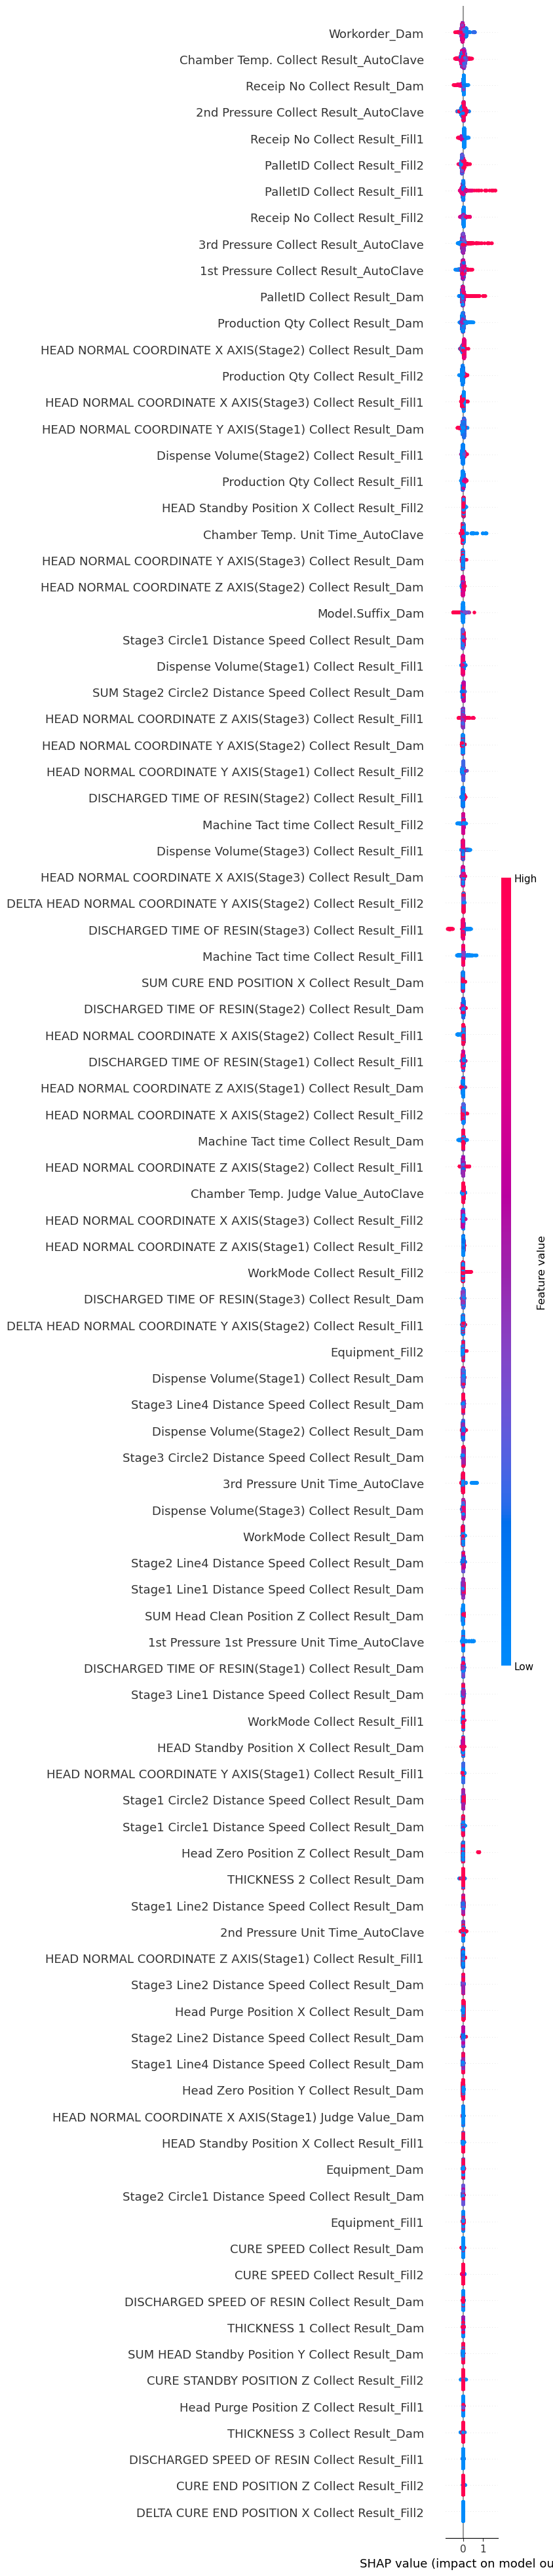

In [ ]:
# 상위 20개 주요 변수 보여줌
shap.summary_plot(shap_values, val_x, max_display=val_x.shape[1])

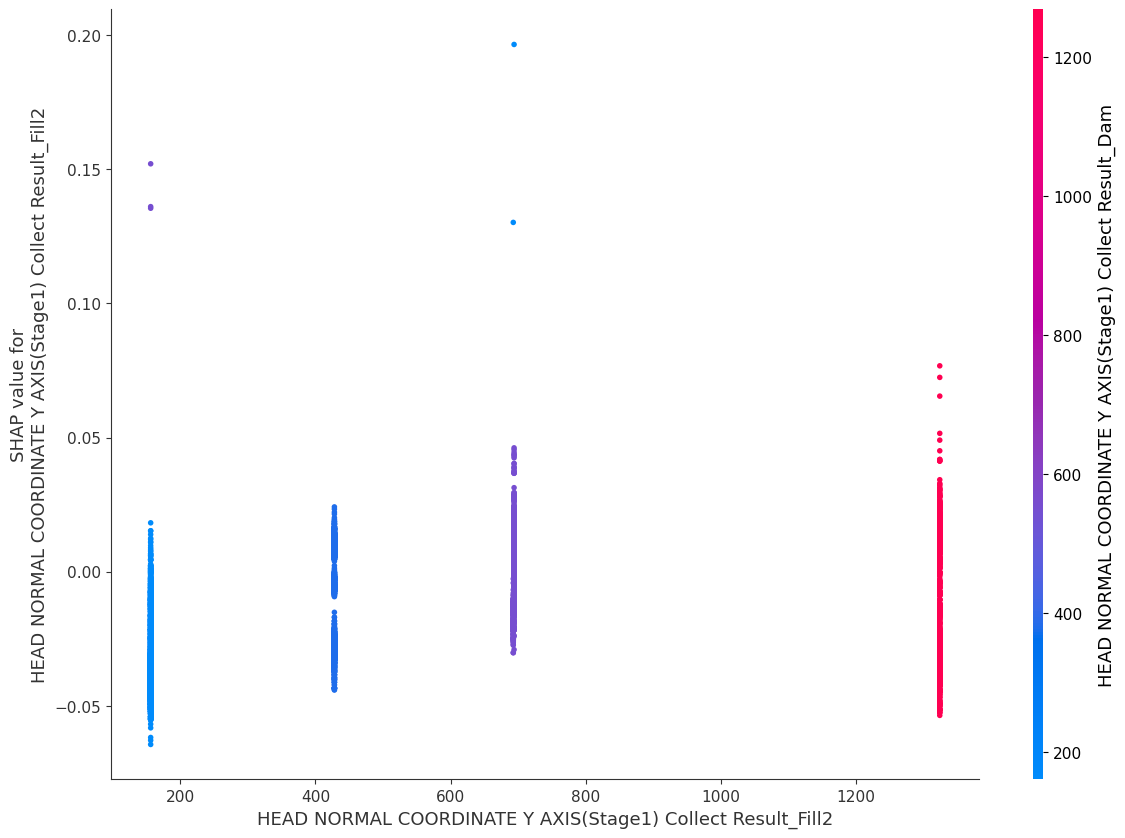

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))  # 너비 14인치, 높이 10인치로 설정

# SHAP dependence plot 생성
shap.dependence_plot(80, shap_values, val_x, ax=ax)

# 그래프 표시
plt.show()

In [ ]:
shap.initjs()
sample_index = 0
shap.force_plot(explainer.expected_value, shap_values[sample_index], val_x.iloc[sample_index, :])